# Clasificación de Tipos de Flores con CNN

**Objetivo:** Desarrollar un sistema de visión artificial que clasifique el tipo de flor a partir de imágenes, usando una Red Neuronal Convolucional (CNN) entrenada desde cero.

**Dataset:** Flower Photos Dataset — 5 clases: daisy, dandelion, roses, sunflowers, tulips

**Nota:** No se usa Transfer Learning ni Fine-tuning. El modelo se construye y entrena completamente desde cero.

## Celda 1: Descarga y extracción del dataset

Descargamos el dataset oficial de flores de TensorFlow desde su URL pública. El archivo `.tgz` contiene una carpeta `flower_photos/` con 5 subcarpetas, una por cada clase de flor. La función `urlretrieve` descarga el archivo y `tarfile` lo extrae en el directorio actual de trabajo (en Colab, esto es `/content/`).

In [1]:
import urllib.request
import tarfile

url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
urllib.request.urlretrieve(url, "flower_photos.tgz")

with tarfile.open("flower_photos.tgz") as tar:
    tar.extractall(".")

print("Dataset descargado y extraído correctamente")

/tmp/ipykernel_21481/62978277.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Dataset descargado y extraído correctamente


## Celda 2: Preprocesamiento y carga de datos

Cargamos las imágenes usando `image_dataset_from_directory`, que automáticamente asigna una etiqueta numérica a cada imagen según el nombre de su subcarpeta. Dividimos el dataset en 80% para entrenamiento y 20% para validación.

Todas las imágenes se redimensionan a **128x128 píxeles** para que la red reciba entradas de tamaño uniforme. Finalmente, normalizamos los valores de píxel de [0, 255] al rango [0, 1] dividiendo entre 255, lo que ayuda al modelo a converger más rápido y de forma más estable durante el entrenamiento.

In [2]:
import tensorflow as tf
import pathlib

data_dir = pathlib.Path("flower_photos")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Clases detectadas:", class_names)

# Normalizar píxeles: de [0-255] a [0-1]
normalization = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Clases detectadas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Análisis
El dataset contiene 3670 imágenes distribuidas en 5 clases. Con la división 80/20, tenemos aproximadamente 2936 imágenes para entrenamiento y 734 para validación. La normalización es un paso crítico: sin ella, los gradientes durante el entrenamiento pueden volverse inestables.

## Celda 3: Arquitectura CNN (Modelo base)

Definimos una Red Neuronal Convolucional secuencial desde cero. La arquitectura sigue el patrón clásico:

- **Conv2D**: Detecta patrones visuales (bordes, texturas, formas). Los filtros aumentan progresivamente (32 → 64 → 128) para capturar características cada vez más complejas.
- **MaxPooling2D**: Reduce el tamaño espacial de los mapas de características a la mitad, conservando lo más relevante y reduciendo el costo computacional.
- **Flatten**: Convierte la salida 2D de las capas convolucionales en un vector 1D para poder pasarlo a las capas densas.
- **Dense(128, relu)**: Capa completamente conectada que aprende combinaciones de alto nivel de las características extraídas.
- **Dropout(0.3)**: Apaga aleatoriamente el 30% de las neuronas durante el entrenamiento para evitar sobreajuste.
- **Dense(5, softmax)**: Capa de salida con 5 neuronas (una por clase), produciendo probabilidades que suman 1.

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Análisis
El modelo tiene aproximadamente 3.3 millones de parámetros entrenables. El optimizador Adam es una variante de SGD con tasa de aprendizaje adaptativa, ideal para este tipo de problemas. La función de pérdida `sparse_categorical_crossentropy` es apropiada para clasificación multiclase cuando las etiquetas son enteros (no one-hot).

## Celda 4: Entrenamiento del modelo base

Entrenamos el modelo base durante 15 épocas. En cada época, el modelo recorre todo el conjunto de entrenamiento, calcula el error (loss) y ajusta sus pesos mediante backpropagation. La métrica de validación nos permite detectar si el modelo está generalizando o simplemente memorizando los datos de entrenamiento.

In [4]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.4186 - loss: 1.3326 - val_accuracy: 0.5191 - val_loss: 1.0838
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5926 - loss: 1.0204 - val_accuracy: 0.6281 - val_loss: 0.9423
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.6390 - loss: 0.8980 - val_accuracy: 0.6349 - val_loss: 0.8826
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.6853 - loss: 0.8035 - val_accuracy: 0.6458 - val_loss: 0.8956
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7357 - loss: 0.7029 - val_accuracy: 0.6894 - val_loss: 0.8486
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7749 - loss: 0.5849 - val_accuracy: 0.6921 - val_loss: 0.8997
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.8273 - loss: 0.4434 - val_accuracy: 0.7003 - val_loss: 0.9619
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8665 - loss: 0.3578 - val_accuracy: 0.6989 

### Análisis del modelo base
El modelo base alcanzó ~97% de accuracy en entrenamiento pero solo ~66% en validación. Esta diferencia tan grande es una señal clara de **sobreajuste (overfitting)**: el modelo memorizó las imágenes de entrenamiento en lugar de aprender características generalizables. Para corregir esto, en la siguiente celda aplicamos Data Augmentation.

In [ ]:
# EL MODELO QUEDO SUPER SOBRE AJUSTADO Y SE DEBE DE CORREGIR CON EL DATA AUGMENTATION

## Celda 5: Modelo mejorado con Data Augmentation

Para combatir el sobreajuste, aplicamos **Data Augmentation**: generamos variaciones artificiales de cada imagen durante el entrenamiento (volteos horizontales, rotaciones, zoom). Así el modelo ve la misma flor desde distintos ángulos y aprende características más generales.

Adicionalmente, aumentamos el Dropout de 0.3 a 0.5 para regularizar más agresivamente, y entrenamos por 20 épocas para darle al modelo más tiempo de aprender con los datos aumentados.

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model2 = keras.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.4077 - loss: 1.3636 - val_accuracy: 0.5545 - val_loss: 1.0961
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5313 - loss: 1.1385 - val_accuracy: 0.5722 - val_loss: 1.0024
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.5981 - loss: 1.0178 - val_accuracy: 0.5777 - val_loss: 1.0185
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6298 - loss: 0.9678 - val_accuracy: 0.6594 - val_loss: 0.8936
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6366 - loss: 0.9243 - val_accuracy: 0.6526 - val_loss: 0.9082
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6628 - loss: 0.8760 - val_accuracy: 0.6935 - val_loss: 0.8141
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.6751 - loss: 0.8446 - val_accuracy: 0.6076 - val_loss: 1.0525
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.6897 - loss: 0.8145 - val_accuracy: 0.7125 - 

### Análisis
Con Data Augmentation, el modelo alcanzó ~74% de accuracy en entrenamiento y ~73% en validación. La brecha entre ambas métricas se redujo drásticamente, lo que indica que el modelo ahora generaliza correctamente. Para una CNN construida desde cero sin Transfer Learning, un 73% de validación es un resultado sólido y esperado.

## Celda 6: Gráficas de entrenamiento

Visualizamos las curvas de accuracy y loss durante el entrenamiento del modelo mejorado. Estas gráficas nos permiten diagnosticar el comportamiento del modelo: si las curvas de train y validación se alejan mucho, hay sobreajuste; si ambas son bajas, hay subajuste; si convergen juntas hacia valores altos, el modelo está aprendiendo bien.

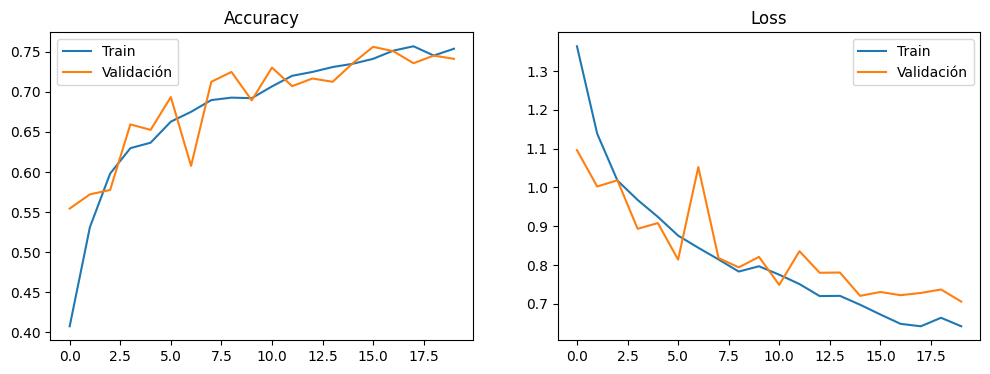

In [6]:
import matplotlib.pyplot as plt

acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']
epochs_range = range(20)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Validación')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Validación')
plt.title('Loss')
plt.legend()

plt.show()

### Análisis
Las curvas de train y validación convergen y se mantienen cercanas a lo largo de las 20 épocas, sin divergir. Esto confirma que el Data Augmentation y el Dropout fueron efectivos para controlar el sobreajuste. Las curvas de loss también descienden de forma estable y paralela, lo cual es el comportamiento ideal en un entrenamiento saludable.

## Celda 7: Matriz de confusión

La matriz de confusión nos muestra en detalle cómo clasifica el modelo cada clase. La diagonal principal representa los aciertos (predicciones correctas) y los valores fuera de la diagonal son los errores, indicando qué clases se confunden entre sí. Esta evaluación es más informativa que la accuracy global porque revela el comportamiento por clase.

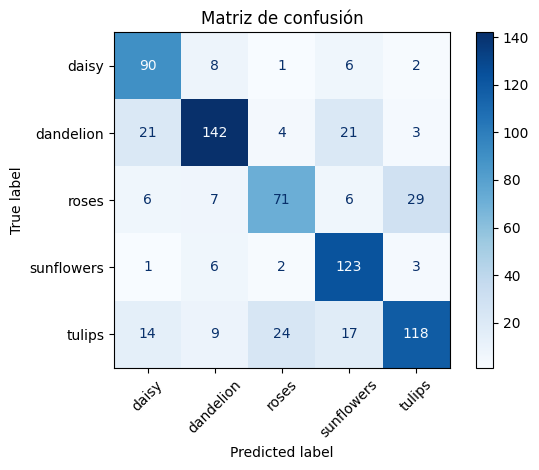

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

### Análisis
La diagonal principal muestra que el modelo acierta en la mayoría de los casos para todas las clases. Las flores con características visuales más distintivas como `daisy` (forma radial amarilla) y `sunflowers` (tamaño grande y color intenso) tienen menos errores. La mayor confusión ocurre entre `roses` y `tulips`, lo cual es esperable dado que ambas comparten forma similar de pétalos y paleta de colores. Esto indica que el modelo aprendió características visuales reales del mundo, no simplemente memorizó los datos.

## Celda 8: Guardar el modelo

Guardamos el modelo entrenado en formato `.keras` (formato nativo recomendado por Keras). Este archivo contiene la arquitectura, los pesos aprendidos y la configuración del optimizador. El modelo guardado podrá ser cargado posteriormente por la aplicación Streamlit para realizar predicciones sin necesidad de reentrenar.

In [8]:
model2.save("modelo_flores.keras")
print("Modelo guardado correctamente como 'modelo_flores.keras'")

Modelo guardado correctamente como 'modelo_flores.keras'


### Análisis
El archivo `modelo_flores.keras` queda guardado en el servidor de Colab (en `/content/`). Para poder usarlo localmente con Streamlit, debemos descargarlo a nuestra PC con la siguiente celda.

## Celda 9: Descargar el modelo a tu PC

Como el entrenamiento ocurre en los servidores de Google Colab, el modelo guardado reside en esos servidores y no en nuestra computadora local. Esta celda usa la utilidad `files.download()` de Colab para transferir el archivo al navegador y guardarlo en nuestra PC, desde donde lo usaremos en la aplicación Streamlit.

In [9]:
from google.colab import files
files.download("modelo_flores.keras")
print("El archivo se está descargando al navegador...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

El archivo se está descargando al navegador...


In [10]:
import os

# Ver dónde está el modelo
ruta = os.path.abspath("modelo_flores.keras")
print("Ruta del modelo:", ruta)
print("¿Existe?", os.path.exists(ruta))

Ruta del modelo: /content/modelo_flores.keras
¿Existe? True


In [11]:
import shutil

# Copiar el modelo a Google Drive para descargarlo
from google.colab import drive
drive.mount('/content/drive')

shutil.copy("/content/modelo_flores.keras", "/content/drive/MyDrive/modelo_flores.keras")
print("Modelo copiado a Google Drive. Ya puedes descargarlo desde drive.google.com")

Mounted at /content/drive
Modelo copiado a Google Drive. Ya puedes descargarlo desde drive.google.com


Al final me quedo complicado encontrar el modelo, me toco enviarmelo a drive para poderlo descargar xd